[INFO] Dataset: 1826 obs × 5 variables
[INFO] Date range: 2021-01-01 → 2025-12-31

[INFO] Applying STL decomposition (period=365) ...
  ozone: seasonal range [-0.0337, 0.0320]
  T2M: seasonal range [-31.3293, 15.1716]
  RH2M: seasonal range [-34.1975, 27.1070]
  PRECTOTCORR: seasonal range [-22.6278, 97.2357]
  WS2M: seasonal range [-2.3140, 5.0340]

[INFO] Running PCMCI+ ...

##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = robust_par_corr
tau_min = 1
tau_max = 7
pc_alpha = [0.01]
max_conds_dim = None
max_combinations = 1



## Resulting lagged parent (super)sets:

    Variable ozone has 3 link(s):
        (ozone -1): max_pval = 0.00000, |min_val| =  0.371
        (RH2M -1): max_pval = 0.00000, |min_val| =  0.135
        (WS2M -1): max_pval = 0.00001, |min_val| =  0.102

    Variable T2M has 4 link(s):
        (T2M -1): max_pval = 0.00000, |min_val| =  0.597
        (PRECTOTCORR -1): max_pval = 0.00000, |min_val| =  0.143
        (RH2M -2

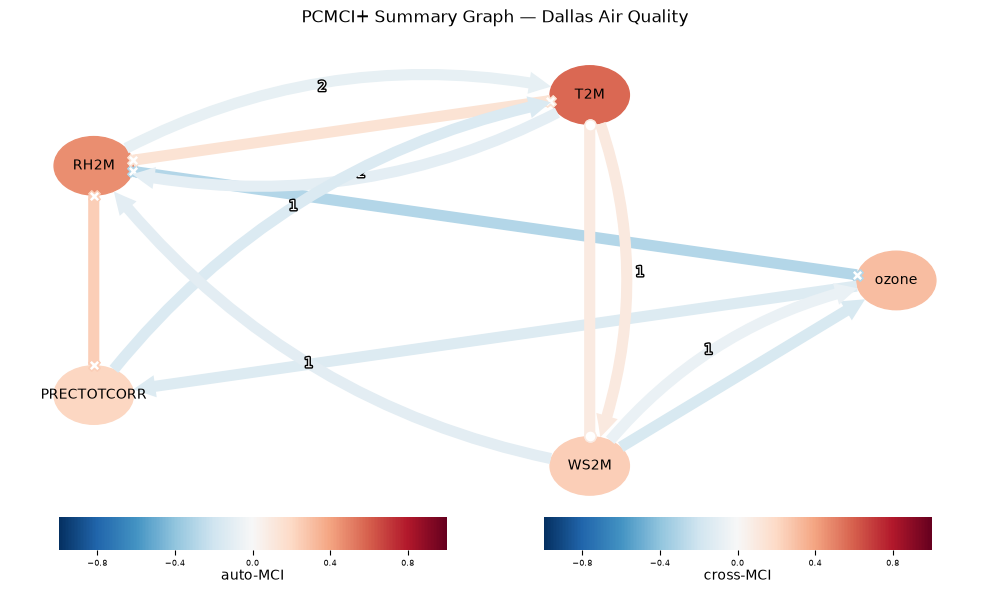

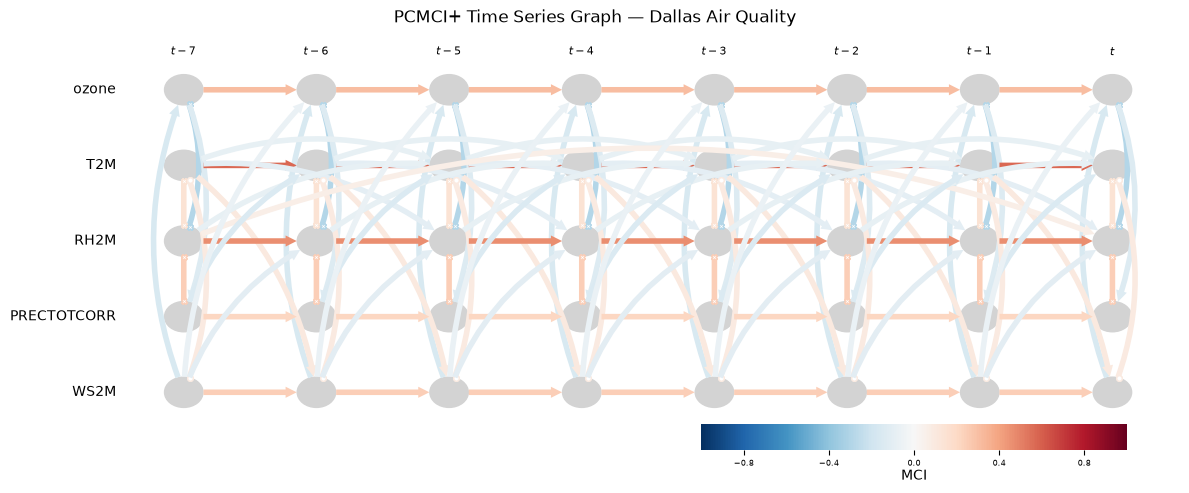

In [27]:
"""
PCMCI+ Causal Discovery — Dallas Air Quality
=============================================
Extends PCMCI to detect contemporaneous (tau=0) causal links in addition
to lagged links — critical for daily data where same-day meteorology ↔
pollutant coupling is physically expected.

Preprocessing: STL decomposition (period=365) to remove annual seasonality.
Test: RobustParCorr: transforms marginals to normality internally for non-Gaussian daily data.
Correction: MCI-based p-values via PCMCI+ internal correction.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL

import tigramite.data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.robust_parcorr import RobustParCorr
from tigramite import plotting as tp

# =============================================================================
# 1. Configuration
# =============================================================================
DATA_PATH   = "datasets/multipollutants_dallas_combined_with_Meteorology.csv"
#FIGURE_DIR  = "figures/"
TAU_MIN     = 0       # tau=0 enables contemporaneous link detection
TAU_MAX     = 7
ALPHA_LEVEL = 0.01    # CHANGED: 0.05 → 0.01 (high-power daily data, n>1000)
STL_PERIOD  = 365

COLS = [
    "ozone",
    "T2M",
    "RH2M",
    "PRECTOTCORR",
    "WS2M",
]

TARGET_VARS = ["ozone"]

# =============================================================================
# 2. Load and sort
# =============================================================================
df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

data_raw = df[COLS].dropna().copy()
print(f"[INFO] Dataset: {len(data_raw)} obs × {len(COLS)} variables")
print(f"[INFO] Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")

# =============================================================================
# 3. STL decomposition — remove annual seasonal cycle, retain residuals
# =============================================================================
print("\n[INFO] Applying STL decomposition (period=365) ...")

residuals = {}
for col in COLS:
    stl = STL(data_raw[col], period=STL_PERIOD, robust=True)
    res = stl.fit()
    residuals[col] = res.resid
    print(f"  {col}: seasonal range [{res.seasonal.min():.4f}, {res.seasonal.max():.4f}]")

data_deseason = pd.DataFrame(residuals)

# =============================================================================
# 4. Standardize
# =============================================================================
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_deseason)

# =============================================================================
# 5. Tigramite dataframe
# =============================================================================
tigramite_df = pp.DataFrame(
    data_scaled,
    var_names=COLS,
    datatime=np.arange(len(data_scaled))
)

# =============================================================================
# 6. PCMCI+
#    run_pcmciplus() detects both lagged (tau>=1) and contemporaneous (tau=0)
#    causal links via skeleton + orientation phases.
#    RobustParCorr: transforms marginals to normality internally — appropriate
#    for non-Gaussian daily air quality/meteorological data. Preferred over
#    standard ParCorr when variables fail normality (all vars: p < 0.001).
#    significance="analytic" avoids permutation overhead.
# =============================================================================

print("\n[INFO] Running PCMCI+ ...")

robust_pc  = RobustParCorr(significance="analytic")

pcmci_plus = PCMCI(
    dataframe=tigramite_df,
    cond_ind_test=robust_pc,
    verbosity=1
)

results = pcmci_plus.run_pcmciplus(
    tau_min=TAU_MIN,
    tau_max=TAU_MAX,
    pc_alpha=ALPHA_LEVEL
)

# =============================================================================
# 7. Graph extraction
#    CHANGED: use results["graph"] directly — this is PCMCI+'s own internally
#    validated graph after MCI correction. Do NOT re-threshold via
#    get_graph_from_pmatrix(), which applies a raw alpha cut on p_matrix
#    without respecting the orientation phase of PCMCI+.
# =============================================================================
graph    = results["graph"]           # CHANGED: was get_graph_from_pmatrix()
p_matrix = results["p_matrix"]

# =============================================================================
# 8. Print significant causal links — contemporaneous and lagged
# =============================================================================
print("\n" + "=" * 60)
print(f"Significant causal links (PCMCI+, alpha={ALPHA_LEVEL})")
print("=" * 60)

for target_name in TARGET_VARS:
    target_idx = COLS.index(target_name)
    print(f"\nTarget: {target_name}")
    print("-" * 40)

    found_any = False

    print("  [Contemporaneous, tau=0]")
    for source_idx, source_name in enumerate(COLS):
        if source_idx == target_idx:
            continue
        pval = p_matrix[source_idx, target_idx, 0]
        val  = results["val_matrix"][source_idx, target_idx, 0]
        if pval < ALPHA_LEVEL:
            found_any = True
            print(
                f"  {source_name}(t) ↔ {target_name}(t) | "
                f"p={pval:.4f}, strength={val:.4f}"
            )

    print("  [Lagged, tau=1..7]")
    for source_idx, source_name in enumerate(COLS):
        for tau in range(1, TAU_MAX + 1):
            pval = p_matrix[source_idx, target_idx, tau]
            val  = results["val_matrix"][source_idx, target_idx, tau]
            if pval < ALPHA_LEVEL:
                found_any = True
                print(
                    f"  {source_name}(t-{tau}) → {target_name}(t) | "
                    f"p={pval:.4f}, strength={val:.4f}"
                )

    if not found_any:
        print("  [none at current alpha]")

# =============================================================================
# 9. Summary graph — variable connections and link strengths
# =============================================================================
tp.plot_graph(
    val_matrix=results["val_matrix"],
    graph=graph,
    var_names=COLS,
    link_colorbar_label="cross-MCI",
    node_colorbar_label="auto-MCI",
    figsize=(10, 6)
)
plt.suptitle("PCMCI+ Summary Graph — Dallas Air Quality", fontsize=12)
plt.tight_layout()
#plt.savefig(f"{FIGURE_DIR}pcmciplus_graph.png", dpi=300, bbox_inches="tight")
plt.show()

# =============================================================================
# 10. Time series graph — full lag structure unrolled across time
#     Use this for detailed lag-specific causal analysis in publications.
# =============================================================================
tp.plot_time_series_graph(
    val_matrix=results["val_matrix"],
    graph=graph,
    var_names=COLS,
    link_colorbar_label="MCI",
    figsize=(12, 5)
)
plt.suptitle("PCMCI+ Time Series Graph — Dallas Air Quality", fontsize=12)
plt.tight_layout()
#plt.savefig(f"{FIGURE_DIR}pcmciplus_tsg.png", dpi=300, bbox_inches="tight")
plt.show()
#print(f"\n[INFO] Figures saved → {FIGURE_DIR}")

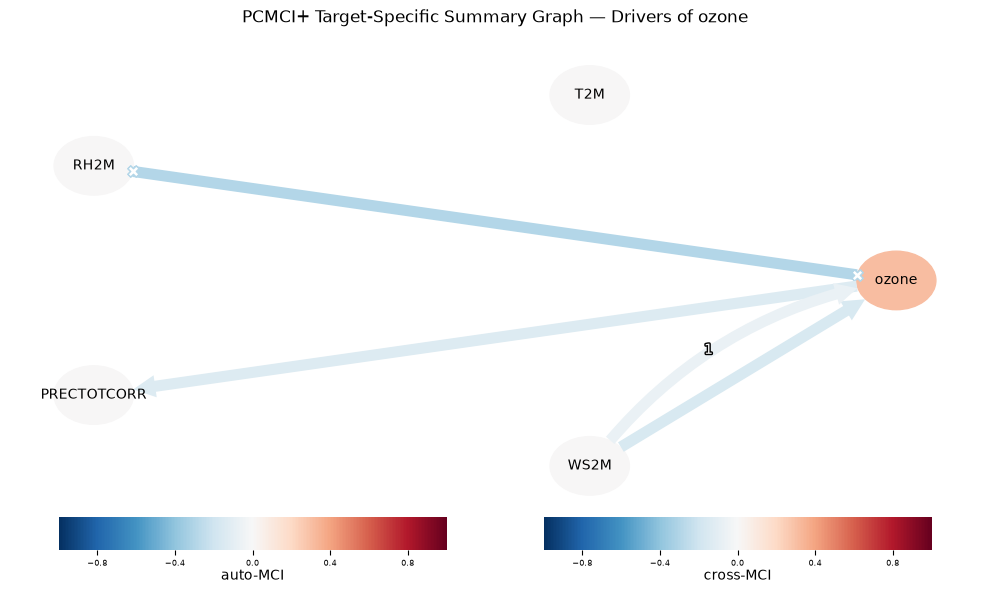

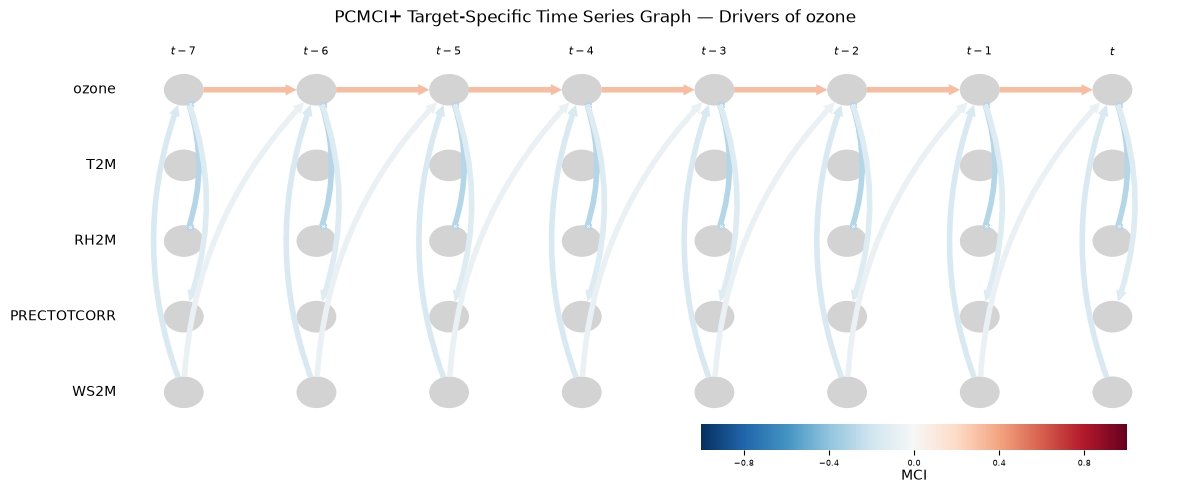

In [29]:
# =============================================================================
# 11. Target-specific PCMCI+ plots — same Tigramite style as Code1
#     Fixed for tau=0 symmetry requirement
# =============================================================================

def make_target_only_graph(graph, target_name, cols):
    target_idx = cols.index(target_name)

    target_graph = np.full(graph.shape, "", dtype=graph.dtype)

    # ---------------------------------------------------------
    # 1. Keep lagged links pointing to the target: tau >= 1
    # ---------------------------------------------------------
    target_graph[:, target_idx, 1:] = graph[:, target_idx, 1:]

    # ---------------------------------------------------------
    # 2. Keep contemporaneous links involving the target: tau = 0
    #    Tigramite requires graph[i,j,0] and graph[j,i,0]
    #    to be consistent.
    # ---------------------------------------------------------
    for source_idx in range(len(cols)):
        if source_idx == target_idx:
            continue

        if graph[source_idx, target_idx, 0] != "":
            target_graph[source_idx, target_idx, 0] = graph[source_idx, target_idx, 0]
            target_graph[target_idx, source_idx, 0] = graph[target_idx, source_idx, 0]

    # Remove self contemporaneous link
    target_graph[target_idx, target_idx, 0] = ""

    return target_graph


target_name = "ozone"

target_graph = make_target_only_graph(
    graph=graph,
    target_name=target_name,
    cols=COLS
)

# =============================================================================
# 12. Target-specific summary graph — same style as Code1
# =============================================================================

tp.plot_graph(
    val_matrix=results["val_matrix"],
    graph=target_graph,
    var_names=COLS,
    link_colorbar_label="cross-MCI",
    node_colorbar_label="auto-MCI",
    figsize=(10, 6)
)

plt.suptitle(f"PCMCI+ Target-Specific Summary Graph — Drivers of {target_name}", fontsize=12)
plt.tight_layout()
plt.show()


# =============================================================================
# 13. Target-specific time series graph — same style as Code1
# =============================================================================

tp.plot_time_series_graph(
    val_matrix=results["val_matrix"],
    graph=target_graph,
    var_names=COLS,
    link_colorbar_label="MCI",
    figsize=(12, 5)
)

plt.suptitle(f"PCMCI+ Target-Specific Time Series Graph — Drivers of {target_name}", fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3440798/2607839773.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


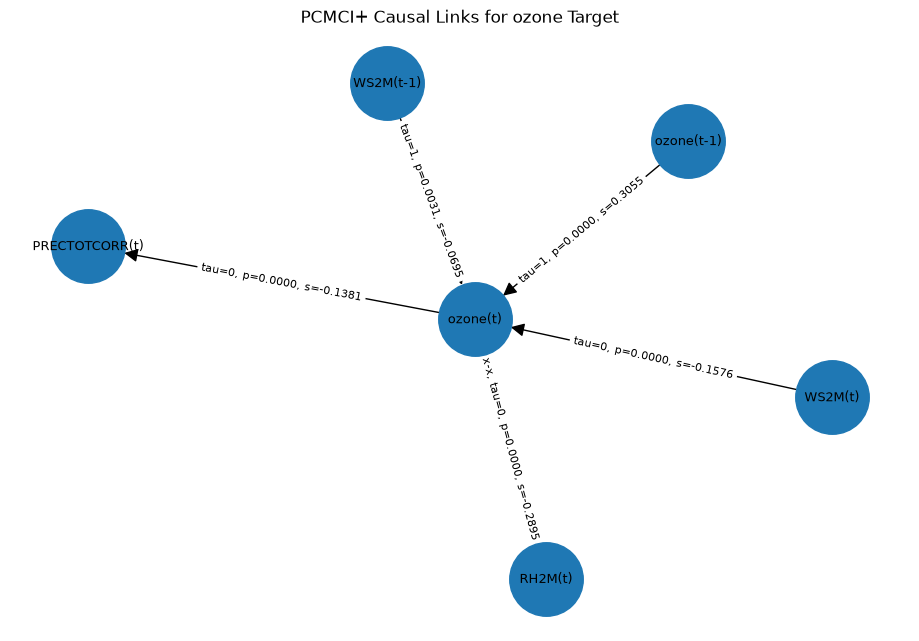

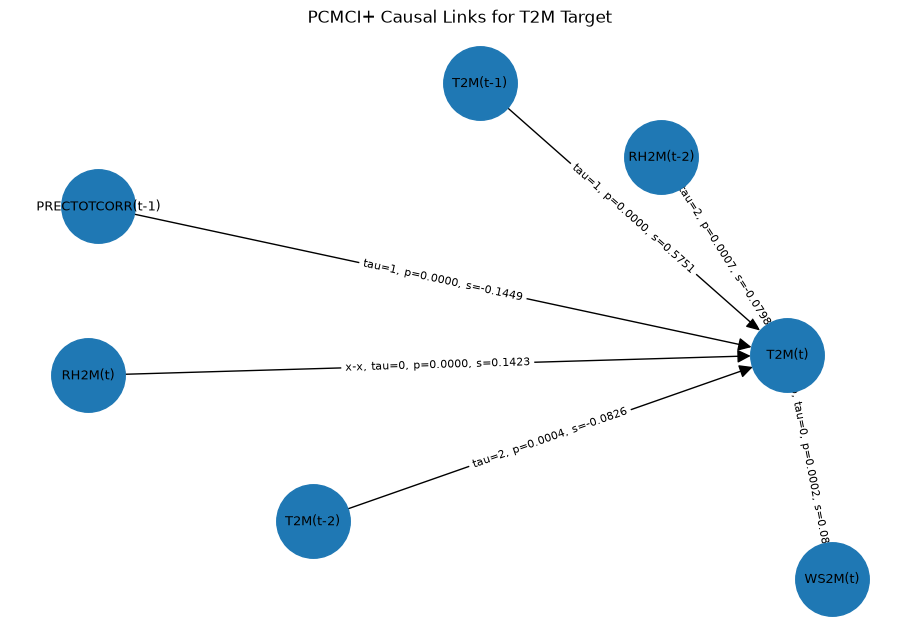

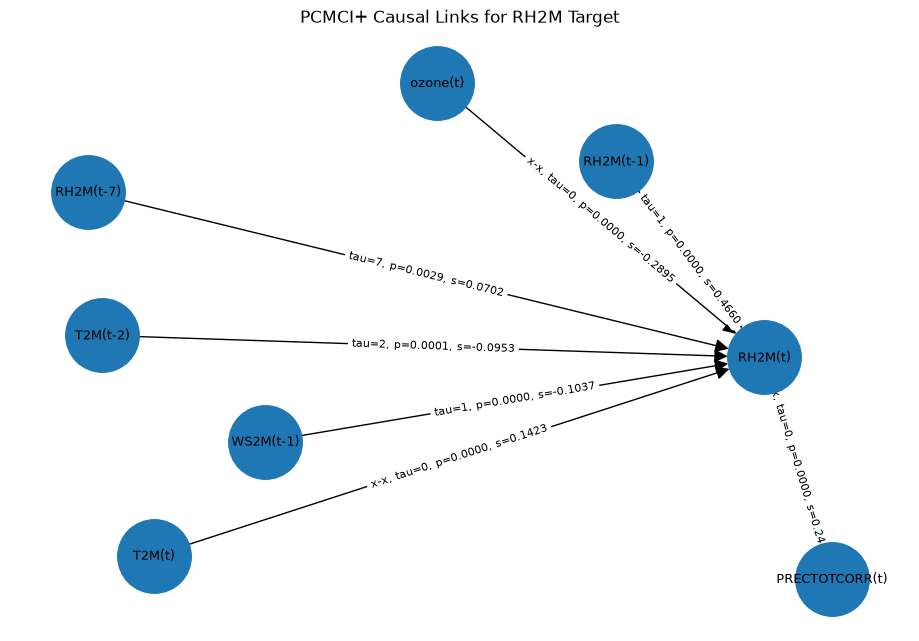

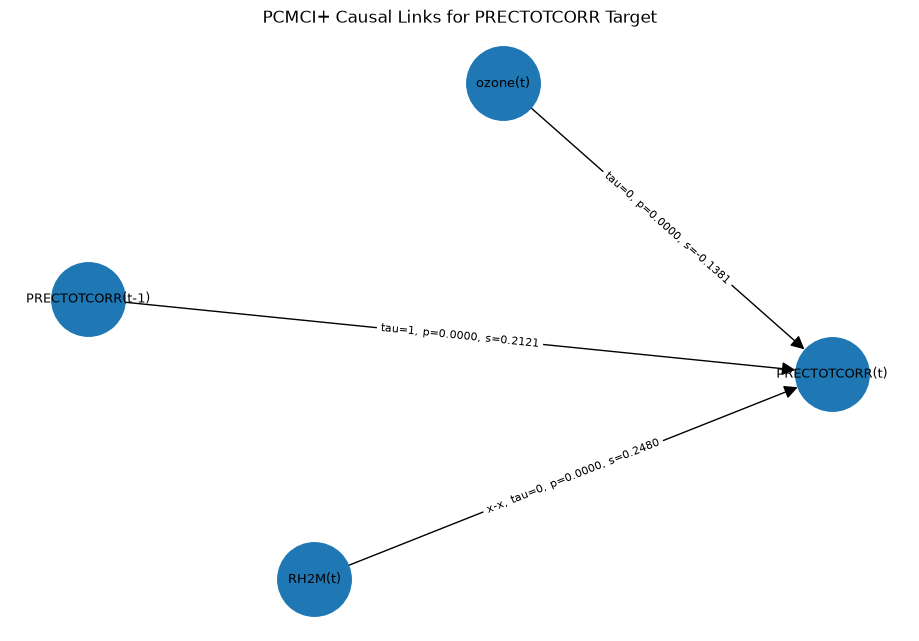

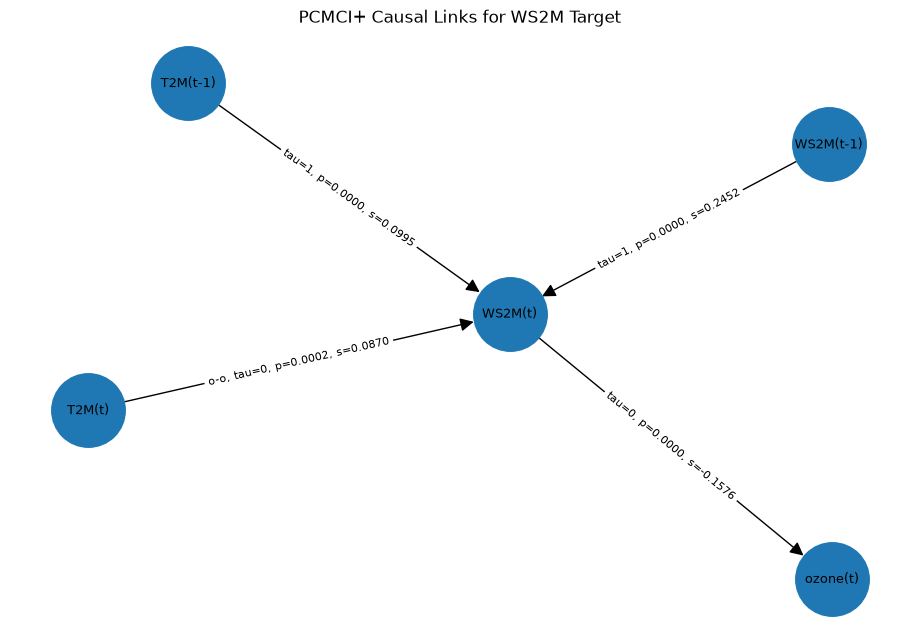

In [31]:
import networkx as nx
import matplotlib.pyplot as plt
import os

def plot_pcmciplus_target_graph(
    cols,
    results,
    tau_max,
    target_variables="ozone",
    alpha_level=0.05,
    save_path=None,
    figsize=(9, 6)
):
    """
    Plot target-specific PCMCI+ causal graph.

    Supports:
    - lagged links: X(t-k) -> Y(t)
    - contemporaneous links: X(t) -- Y(t), including unclear/unoriented links
    """

    graph = results["graph"]          # IMPORTANT for PCMCI+
    p_matrix = results["p_matrix"]
    val_matrix = results["val_matrix"]

    # -------------------------
    # Select target variables
    # -------------------------
    if target_variables == "all":
        selected_targets = cols
    elif isinstance(target_variables, str):
        selected_targets = [target_variables]
    elif isinstance(target_variables, list):
        selected_targets = target_variables
    else:
        raise ValueError("target_variables must be 'all', a string, or a list.")

    # -------------------------
    # Validate target names
    # -------------------------
    for target in selected_targets:
        if target not in cols:
            raise ValueError(f"Target '{target}' is not in cols. Available variables: {cols}")

    # -------------------------
    # Plot one graph per target
    # -------------------------
    for target_name in selected_targets:
        target_idx = cols.index(target_name)

        G_target = nx.DiGraph()

        for source_idx, source_name in enumerate(cols):

            # =========================
            # tau = 0 contemporaneous links
            # =========================
            tau = 0

            if source_idx != target_idx:
                link_type = graph[source_idx, target_idx, tau]
                pval = p_matrix[source_idx, target_idx, tau]
                strength = val_matrix[source_idx, target_idx, tau]

                if link_type != "" and pval < alpha_level:

                    source_label = f"{source_name}(t)"
                    target_label = f"{target_name}(t)"

                    # PCMCI+ orientation handling
                    if link_type == "-->":
                        edge_label = f"tau=0, p={pval:.4f}, s={strength:.4f}"
                        G_target.add_edge(
                            source_label,
                            target_label,
                            label=edge_label,
                            link_type=link_type
                        )

                    elif link_type == "<--":
                        edge_label = f"tau=0, p={pval:.4f}, s={strength:.4f}"
                        G_target.add_edge(
                            target_label,
                            source_label,
                            label=edge_label,
                            link_type=link_type
                        )

                    else:
                        # For unclear/unoriented/conflict contemporaneous links
                        # Examples: "o-o", "x-x"
                        edge_label = f"{link_type}, tau=0, p={pval:.4f}, s={strength:.4f}"
                        G_target.add_edge(
                            source_label,
                            target_label,
                            label=edge_label,
                            link_type=link_type
                        )

            # =========================
            # tau = 1..tau_max lagged links
            # =========================
            for tau in range(1, tau_max + 1):

                link_type = graph[source_idx, target_idx, tau]
                pval = p_matrix[source_idx, target_idx, tau]
                strength = val_matrix[source_idx, target_idx, tau]

                if link_type != "" and pval < alpha_level:

                    source_label = f"{source_name}(t-{tau})"
                    target_label = f"{target_name}(t)"

                    edge_label = f"tau={tau}, p={pval:.4f}, s={strength:.4f}"

                    G_target.add_edge(
                        source_label,
                        target_label,
                        label=edge_label,
                        link_type=link_type
                    )

        if G_target.number_of_edges() == 0:
            print(f"No significant links found for target: {target_name}")
            continue

        plt.figure(figsize=figsize)
        pos = nx.spring_layout(G_target, seed=42)

        nx.draw(
            G_target,
            pos,
            with_labels=True,
            node_size=2800,
            font_size=9,
            arrows=True,
            arrowsize=20
        )

        edge_labels = {
            (u, v): d["label"]
            for u, v, d in G_target.edges(data=True)
        }

        nx.draw_networkx_edge_labels(
            G_target,
            pos,
            edge_labels=edge_labels,
            font_size=8
        )

        plt.title(f"PCMCI+ Causal Links for {target_name} Target")
        plt.axis("off")
        plt.tight_layout()

        if save_path is not None:
            os.makedirs(save_path, exist_ok=True)
            file_path = os.path.join(save_path, f"pcmciplus_{target_name}_target_graph.png")
            #plt.savefig(file_path, dpi=300, bbox_inches="tight")
            #print(f"Saved graph: {file_path}")

        plt.show()

plot_pcmciplus_target_graph(
    cols=COLS,
    results=results,
    tau_max=TAU_MAX,
    target_variables="all",
    alpha_level=ALPHA_LEVEL,
    save_path=None
)